In [1]:
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [ ]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Defining file path for saving dataset and loading it later on.

In [ ]:
file_path = 'data/bpmnmodelset/processed/culled_models.csv'


In [ ]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'



extract_names_from_models(bpmn_dataset, use_types=use_types)


In [ ]:
from mcp4cm.bpmn.data_extraction import filter_empty_models

print(bpmn_dataset)

filter_empty_models(bpmn_dataset, key=key, inplace=True, empty_name=empty_name)

print(bpmn_dataset)

In [ ]:
from mcp4cm.generic.language_detection import detect_dataset_languages
from mcp4cm.bpmn.data_extraction import extract_model_languages

extract_model_languages(bpmn_dataset, key=key, empty_name=empty_name)


In [ ]:
language_dict = detect_dataset_languages(bpmn_dataset)

In [ ]:
from mcp4cm.generic.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)
language_dict = detect_dataset_languages(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


In [ ]:
del(english_dataset)

In [19]:
from mcp4cm.bpmn.dataloading import load_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/reduced/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

In [20]:
len(loaded_dataset)

17204


=== Dataset Statistics ===
Duplicate Detection on already computed hashes took 0.00 seconds.
Total number of models: 17204
Total unique files: 9006
Total duplicate files: 8198
Number of duplicate groups: 111


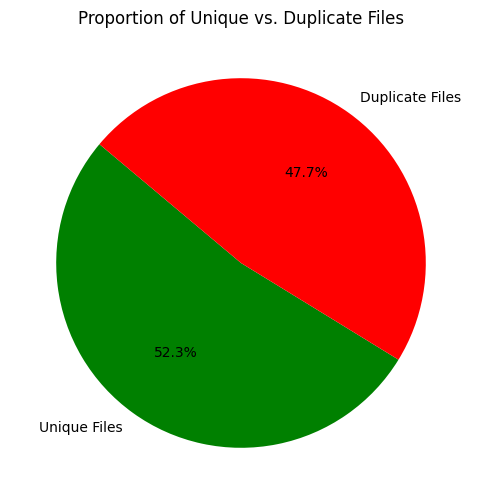

In [21]:
from mcp4cm.bpmn.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=False, plt_fig=True, print_results=True)


Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 17204
Total unique files: 7361
Total duplicate files: 9843
Number of duplicate groups: 0


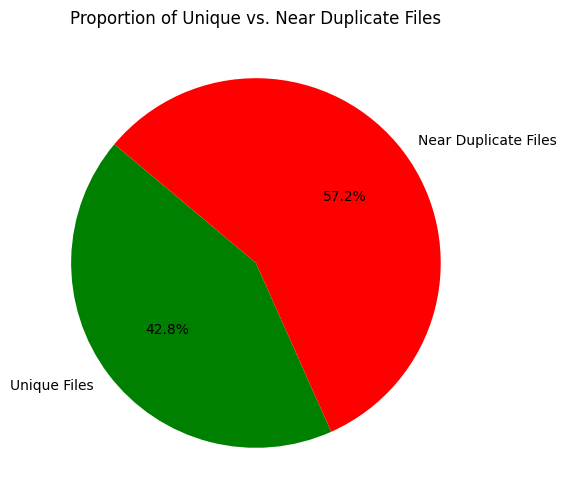

In [22]:
from mcp4cm.bpmn.duplicate_detection import tfidf_graph_near_duplicate_detector
key = 'names'
tfidf_graph_near_duplicate_detector(loaded_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)

In [ ]:
file_path = 'data/bpmnmodelset/processed/english_deduplicated_models.csv'
BPMNDataset.to_csv(loaded_dataset, file_path);